# Clouds Everywhere — Demo 2
A deeper look at the library: multiple AOI formats, stricter cloud thresholds,
satellite comparison, cloud timelines, and the interactive tile map.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))

from aoi import to_bbox
from search import search_images
from coverage import check_coverage
from viz import plot_coverage_heatmap, plot_cloud_timeline, plot_satellite_comparison
import pandas as pd

print('Library loaded.')

Library loaded.


## 1. Three ways to define the same AOI

The library accepts a plain bbox, a polygon ring, or a GeoJSON dict — all normalised
to WGS84 automatically.

In [2]:
# Plain bbox [minLon, minLat, maxLon, maxLat]
aoi_bbox = [-4.5, 39.5, -2.5, 41.0]

# Polygon ring (lon, lat pairs)
aoi_ring = [
    [-4.5, 39.5], [-2.5, 39.5],
    [-2.5, 41.0], [-4.5, 41.0],
    [-4.5, 39.5],
]

# GeoJSON Feature
aoi_geojson = {
    'type': 'Feature',
    'geometry': {
        'type': 'Polygon',
        'coordinates': [[
            [-4.5, 39.5], [-2.5, 39.5],
            [-2.5, 41.0], [-4.5, 41.0],
            [-4.5, 39.5],
        ]]
    },
    'properties': {}
}

for label, aoi in [('bbox', aoi_bbox), ('ring', aoi_ring), ('GeoJSON', aoi_geojson)]:
    print(f'{label:8s} → {to_bbox(aoi)}')

bbox     → [-4.5, 39.5, -2.5, 41.0]
ring     → [-4.5, 39.5, -2.5, 41.0]
GeoJSON  → [-4.5, 39.5, -2.5, 41.0]


## 2. Strict vs. relaxed cloud threshold

Same AOI, same date range — only the threshold changes.

In [3]:
aoi        = aoi_geojson
start_date = '2024-01-01'
end_date   = '2024-03-31'

for threshold in [10, 20, 40]:
    imgs = search_images(aoi, start_date, end_date,
                         max_cloud=threshold, satellites=['sentinel2'])
    print(f'  max_cloud={threshold:3d}%  →  {len(imgs):3d} Sentinel-2 scenes')

  max_cloud= 10%  →   50 Sentinel-2 scenes


  max_cloud= 20%  →   74 Sentinel-2 scenes


  max_cloud= 40%  →  106 Sentinel-2 scenes


## 3. Multi-satellite search

Search Sentinel-2 and Landsat together, then compare counts.

In [4]:
images = search_images(aoi, start_date, end_date, max_cloud=20)
print(f'Total: {len(images)} images')

df = pd.DataFrame([
    {'Date': img.date, 'Satellite': img.satellite, 'Cloud %': round(img.cloud_cover, 1)}
    for img in images
])
df.groupby('Satellite').agg(
    Scenes=('Date', 'count'),
    Avg_Cloud=('Cloud %', 'mean'),
    Best_Cloud=('Cloud %', 'min'),
).round(1)

Total: 86 images


,Scenes,Avg_Cloud,Best_Cloud
Satellite,,,
Sentinel-2,74,7.3,0.0
landsat-8,3,14.3,9.4
landsat-9,9,8.3,0.0


## 4. Tile coverage check — all satellites

In [5]:
cov = check_coverage(aoi, start_date, end_date, max_cloud=20)
print(f'{len(cov)} satellite-date combinations')

cov_df = pd.DataFrame([
    {
        'Date':      c.date,
        'Satellite': c.satellite,
        'Status':    c.status,
        'Covered':   f"{len(c.covered_tiles)}/{len(c.required_tiles)}",
        'Avg Cloud': round(c.avg_cloud, 1) if c.avg_cloud != -1 else 'N/A',
    }
    for c in cov
])
cov_df

70 satellite-date combinations


,Date,Satellite,Status,Covered,Avg Cloud
0,2024-01-01,Sentinel-2,partial,3/9,13.8
1,2024-01-03,Sentinel-2,missing,0/9,N/A
2,2024-01-04,landsat-9,missing,0/9,N/A
3,2024-01-05,landsat-8,missing,0/9,N/A
4,2024-01-06,Sentinel-2,partial,5/9,9.0
...,...,...,...,...,...
65,2024-03-25,landsat-8,missing,0/9,N/A
66,2024-03-26,Sentinel-2,missing,0/9,N/A
67,2024-03-26,landsat-9,missing,0/9,N/A
68,2024-03-28,Sentinel-2,missing,0/9,N/A


In [6]:
fully_clear = [c for c in cov if c.status == 'full']
print(f'Dates with FULL coverage: {len(fully_clear)}')
for c in fully_clear:
    print(f'  {c}')

Dates with FULL coverage: 3
  2024-01-08 | Sentinel-2 | FULL (9/9 tiles) avg cloud: 4.6%
  2024-02-02 | Sentinel-2 | FULL (9/9 tiles) avg cloud: 5.0%
  2024-02-17 | Sentinel-2 | FULL (9/9 tiles) avg cloud: 0.8%


## 5. Satellite comparison

How many dates are fully covered, partially covered, or missing — per satellite.

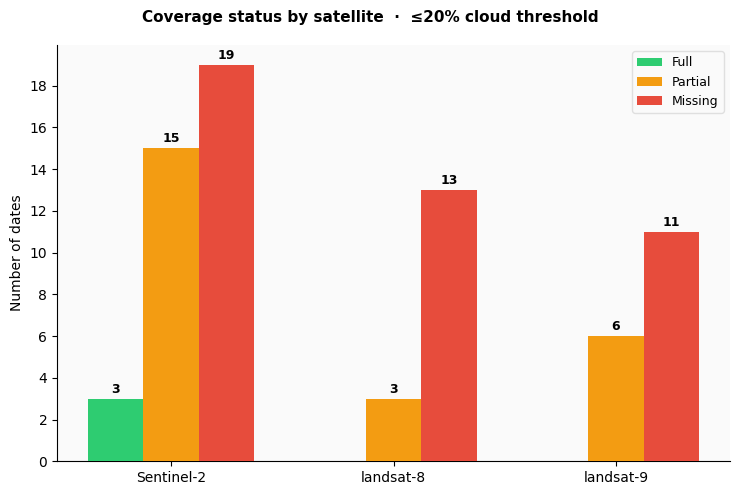

In [7]:
fig = plot_satellite_comparison(cov, max_cloud=20)

## 6. Tile coverage heatmap

Each cell = cloud % for that tile on that date.
Grey = no satellite pass. Top strip = date-level status.

In [8]:
fig = plot_coverage_heatmap(cov, max_cloud=20, satellite='Sentinel-2')

In [9]:
fig = plot_coverage_heatmap(cov, max_cloud=20, satellite='landsat-9')

## 7. Cloud % timeline per tile

Tracks each tile's cloud cover over time. The green band marks the usable zone.

In [10]:
fig = plot_cloud_timeline(cov, max_cloud=20, satellite='Sentinel-2')

## 8. Effect of a strict 10% cloud threshold

Re-run coverage with a tighter threshold to see how many dates survive.

In [11]:
cov_strict = check_coverage(aoi, start_date, end_date, max_cloud=10)
full_strict = [c for c in cov_strict if c.status == 'full']
print(f'Fully clear dates at ≤10% cloud: {len(full_strict)}')
for c in full_strict:
    print(f'  {c}')

fig = plot_coverage_heatmap(cov_strict, max_cloud=10, satellite='Sentinel-2')

Fully clear dates at ≤10% cloud: 1
  2024-02-17 | Sentinel-2 | FULL (9/9 tiles) avg cloud: 0.8%


## 9. Different region — Nile Delta, Egypt

Switch AOI to a completely different geography to show the library is region-agnostic.

In [12]:
nile_delta = {
    'type': 'Feature',
    'geometry': {
        'type': 'Polygon',
        'coordinates': [[
            [30.0, 30.0], [32.5, 30.0],
            [32.5, 31.5], [30.0, 31.5],
            [30.0, 30.0],
        ]]
    },
    'properties': {}
}

nile_images = search_images(
    nile_delta,
    '2024-01-01', '2024-01-31',
    max_cloud=20,
    satellites=['sentinel2', 'landsat'],
)
print(f'Nile Delta — {len(nile_images)} scenes in Jan 2024')

pd.DataFrame([
    {'Date': img.date, 'Satellite': img.satellite, 'Cloud %': round(img.cloud_cover, 1)}
    for img in nile_images
]).groupby('Satellite').size().rename('Scenes').reset_index()

Nile Delta — 59 scenes in Jan 2024


,Satellite,Scenes
0,Sentinel-2,41
1,landsat-8,11
2,landsat-9,7


In [13]:
nile_cov = check_coverage(
    nile_delta,
    '2024-01-01', '2024-01-31',
    max_cloud=20,
)
fig = plot_coverage_heatmap(nile_cov, max_cloud=20, satellite='Sentinel-2')

## 10. Interactive spatial tile map — Madrid region

Tiles coloured by usability across the full 3-month window.

In [14]:
import folium
from collections import defaultdict

tile_stats = defaultdict(lambda: {'clouds': [], 'geometry': None})
for c in cov:
    for tr in c.tile_details:
        ts = tile_stats[tr.tile_id]
        if tr.geometry and ts['geometry'] is None:
            ts['geometry'] = tr.geometry
        if tr.cloud_cover != -1:
            ts['clouds'].append(tr.cloud_cover)

def tile_color(clouds, threshold):
    if not clouds: return '#95a5a6'
    usable = sum(1 for c in clouds if c <= threshold) / len(clouds)
    if usable >= 0.6: return '#2ecc71'
    if usable >= 0.3: return '#f39c12'
    if usable  > 0:   return '#e74c3c'
    return '#95a5a6'

aoi_bbox = to_bbox(aoi)
m = folium.Map(location=[40.0, -3.5], zoom_start=7, tiles='CartoDB positron')

folium.Rectangle(
    bounds=[[aoi_bbox[1], aoi_bbox[0]], [aoi_bbox[3], aoi_bbox[2]]],
    color='#2980b9', weight=2.5, fill=True, fill_opacity=0.08,
    tooltip='Analysis AOI (Madrid region)'
).add_to(m)

for tile_id, ts in tile_stats.items():
    if not ts['geometry']: continue
    clouds = ts['clouds']
    color  = tile_color(clouds, 20)
    best   = f'{min(clouds):.1f}' if clouds else 'N/A'
    usable = sum(1 for c in clouds if c <= 20)
    tooltip = (
        f'<b>Tile {tile_id}</b><br>'
        f'Best cloud: {best}%<br>'
        f'Usable dates: {usable}/{len(clouds)}'
    )
    folium.GeoJson(
        ts['geometry'],
        style_function=lambda _, c=color: {
            'fillColor': c, 'color': 'white',
            'weight': 1.0, 'fillOpacity': 0.6
        },
        tooltip=folium.Tooltip(tooltip, sticky=False)
    ).add_to(m)

legend = '''
<div style="position:fixed;bottom:24px;left:24px;z-index:1000;
            background:white;padding:10px 14px;border-radius:8px;
            box-shadow:0 1px 5px rgba(0,0,0,.25);font-size:12px;line-height:1.9">
  <b>Tile usability (% of dates ≤20% cloud)</b><br>
  <span style="background:#2ecc71;padding:2px 12px;border-radius:3px">&nbsp;</span> ≥60%<br>
  <span style="background:#f39c12;padding:2px 12px;border-radius:3px">&nbsp;</span> 30–60%<br>
  <span style="background:#e74c3c;padding:2px 12px;border-radius:3px">&nbsp;</span> &lt;30%<br>
  <span style="background:#95a5a6;padding:2px 12px;border-radius:3px">&nbsp;</span> No data
</div>
'''
m.get_root().html.add_child(folium.Element(legend))
m